# Multi-Layer Perceptron

## 1. Introducing Layers that "Learn" Basis Functions

A Multi-Layer Perceptron (MLP) is a neural network that consists of an input layer, one or more hidden layers, and an output layer. Each layer is made up of neurons that are connected to the neurons in the next layer. MLPs are fully connected networks, meaning every neuron in one layer connects to every neuron in the following layer.

MLPs are commonly used for classification and regression tasks.

In each layer, the network processes the input data by applying a linear transformation using weights and biases, followed by a non-linear activation function such as the sigmoid function. The model learns by adjusting its weights and biases through backpropagation. This process minimizes the error between the model predictions and the true target values.

In this exercise, you will implement parts of an MLP from scratch. First, you will complete the forward pass to generate predictions. Then, you will complete the backward pass to update the weights using gradient descent.

---

### Tasks

- **Compute the Forward Pass**

  Given an input, complete the forward pass through the network.

  You will:
  - add the bias term to the hidden layer output,
  - compute the linear input to the output layer,
  - apply the activation function,
  - calculate the final output of the network.

- **Implement the Backward Pass**

  Starting from the output error, calculate the gradients needed to update the weights.

  The gradient for the output layer is already provided. Your task is to work backwards and compute the gradient for the hidden layer.

  You will:
  - propagate the output error backwards through the output layer weights,
  - ignore the bias weight when propagating error to the hidden layer,
  - apply the derivative of the hidden activation function,
  - compute the gradient for the input-to-hidden weights,
  - update both weight matrices.

- **Analyze Weight Initialization**

  Consider why we do not initialize all weights with zero.

  Think about:
  - what happens during the forward pass,
  - what happens during backpropagation,
  - why hidden neurons need different initial weights.

---

### Notes

- Use the chain rule to calculate the delta values that propagate backwards through the network.
- The output layer gradient is partly provided.
- The hidden layer gradient needs to be completed.
- Both layers are trainable.
- The model uses sigmoid activation and Mean Squared Error (MSE) for this exercise.

---

### Analysis

Test different hyperparameters in your implementation:

- learning rate,
- number of hidden neurons,
- number of training iterations,
- weight initialization strategy.

Observe how these choices affect training.

Consider the following questions:

- Does the loss decrease during training?
- Does the model converge faster or slower?
- What happens if the learning rate is too large or too small?
- What happens when the hidden layer has very few or many neurons?
- Why does random initialization work better than zero initialization?
- How could the method be improved?

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Define custom centers for the dataset
centers = [(-2, 2), (-2, -2), (2, 2), (2, -2)]  # Four centers
cluster_std = 1.0  # Standard deviation for each cluster

# Generate synthetic dataset
X, y = make_blobs(n_samples=1000, centers=centers, cluster_std=cluster_std, random_state=42)

# Map clusters to two classes: 0 and 1
# Assign class 0 to clusters 0 and 1, and class 1 to clusters 2 and 3
y = (y == 1) | (y == 2)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


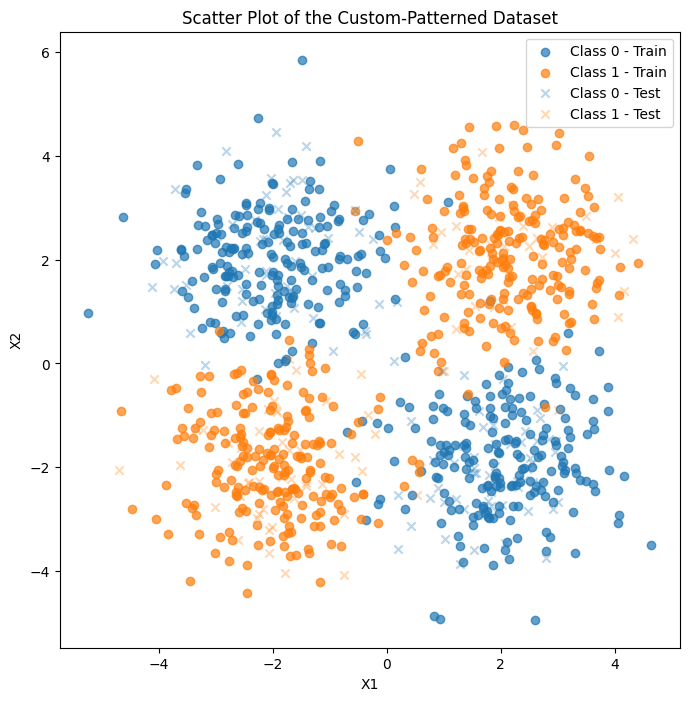

In [2]:
# Plot the dataset
plt.figure(figsize=(8, 8))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='C0', alpha=0.7, label='Class 0 - Train')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='C1', alpha=0.7, label='Class 1 - Train')
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], color='C0', alpha=0.3, marker='x', label='Class 0 - Test')
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], color='C1', alpha=0.3, marker='x', label='Class 1 - Test')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Scatter Plot of the Custom-Patterned Dataset')
plt.legend()
plt.show()

In [3]:
class SigmoidActivationFunction:
    """
    A class implementing the sigmoid activation function and its derivative.
    """

    def __call__(self, x):
        """
        Calculate the sigmoid activation function for a given input x.

        Parameters:
        x : np.array or float
            The input value(s) to the sigmoid function.

        Returns:
        np.array or float
            The sigmoid function output for each element in x.
        """
        return 1 / (1 + np.exp(-x))

    def derivative(self, x):
        """
        Calculate the derivative of the sigmoid function for a given input x.

        Parameters:
        x : np.array or float
            The input value(s) to the sigmoid function.

        Returns:
        np.array or float
            The derivative of the sigmoid function for each element in x.
        """
        sigmoid_x = self.__call__(x)
        return sigmoid_x * (1 - sigmoid_x)


In [4]:
import numpy as np
from sklearn.metrics import mean_squared_error


class MLPClass:
    """
    A simple Multi-Layer Perceptron with one hidden layer.

    Architecture:
        input layer -> hidden layer -> output layer

    Both layers are trainable and optimized using gradient descent.
    """

    def __init__(self, input_dim, hidden_dim=4, learning_rate=0.01, n_iterations=1000):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.mse_history = []

        self.activation_function = SigmoidActivationFunction()

        # TODO:
        # Why should we not initialize all weights with zeros?
        # Hint: think about what happens to hidden neurons during backpropagation.
        self.weights = [
            np.random.randn(hidden_dim, input_dim + 1) * np.sqrt(1 / input_dim),
            np.random.randn(1, hidden_dim + 1) * np.sqrt(1 / hidden_dim)
        ]

    def add_bias_column(self, X):
        """
        Add a bias column of ones to the input matrix.
        """
        return np.c_[np.ones(X.shape[0]), X]

    def forward(self, X):
        """
        Perform the forward pass.

        Returns:
            output: final prediction
            hidden_output_with_bias: hidden activations with bias column
            hidden_input: linear input to hidden layer
            output_input: linear input to output layer
        """

        # Input -> hidden layer
        X_with_bias = self.add_bias_column(X)
        hidden_input = np.dot(X_with_bias, self.weights[0].T)
        hidden_output = self.activation_function(hidden_input)

        # TODO 1:
        # Complete the forward pass from hidden layer to output layer.
        # Steps:
        # 1. Add a bias column to hidden_output.
        # 2. Compute the linear input to the output layer.
        # 3. Apply the activation function.

        hidden_output_with_bias = self.add_bias_column(hidden_output)
        output_input = np.dot(hidden_output_with_bias, self.weights[1].T)
        output = self.activation_function(output_input)

        return output, hidden_output_with_bias, hidden_input, output_input

    def predict(self, X):
        """
        Predict binary class labels.
        """
        output, _, _, _ = self.forward(X)
        return (output > 0.5).astype(int)

    def binary_crossentropy(self, y_true, y_pred):
        """
        Binary cross-entropy loss.
        """
        epsilon = 1e-12
        y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)

        return -np.mean(
            y_true * np.log(y_pred) +
            (1 - y_true) * np.log(1 - y_pred)
        )

    def fit(self, X, y):
        """
        Train the model using gradient descent.
        """
        y = y.reshape(-1, 1)
        X_with_bias = self.add_bias_column(X)

        for _ in range(self.n_iterations):
            # Forward pass
            output, hidden_output_with_bias, hidden_input, output_input = self.forward(X)

            # Store MSE for visualization
            mse = mean_squared_error(y, output)
            self.mse_history.append(mse)

            # Output layer delta
            output_error = output - y
            output_delta = output_error * self.activation_function.derivative(output_input)

            # Gradient for hidden -> output weights
            output_gradient = np.dot(output_delta.T, hidden_output_with_bias) / X.shape[0]

            # TODO 2:
            # Complete the backward pass for the hidden layer.
            # Steps:
            # 1. Propagate output_delta backwards through the output layer weights.
            # 2. Do not use the bias weight when propagating the error backwards.
            # 3. Multiply by the derivative of the hidden activation.
            # 4. Compute the gradient for the input -> hidden weights.

            hidden_error = np.dot(output_delta, self.weights[1][:, 1:])
            hidden_delta = hidden_error * self.activation_function.derivative(hidden_input)
            hidden_gradient = np.dot(hidden_delta.T, X_with_bias) / X.shape[0]

            # Update both trainable layers
            self.weights[1] -= self.learning_rate * output_gradient
            self.weights[0] -= self.learning_rate * hidden_gradient

    def get_mse_history(self):
        """
        Return MSE values collected during training.
        """
        return self.mse_history

<details>
<summary>Click to see math formulas for Backpropagation</summary>

## Gradient Computation for MLP


### Step 1: Compute Delta for Output Layer (as before)

For a single output neuron, the Mean Squared Error (MSE) loss $L$ is defined as:

$$
L = \frac{1}{2} (y_{\text{pred}} - y_{\text{true}})^2
$$

The gradient of the loss with respect to the output $ y_{\text{pred}} $ is:

$$
\frac{\partial L}{\partial y_{\text{pred}}} = y_{\text{pred}} - y_{\text{true}}
$$

The output $ y_{\text{pred}} $ is obtained by applying the activation function (e.g., sigmoid) to the linear combination of the hidden layer outputs. Let’s define:
- $ z_{\text{out}} $ as the linear combination before applying the activation function,
- $ a_{\text{out}} = \sigma(z_{\text{out}}) $ as the activated output, where $ \sigma $ is the activation function.

We are introducing a shorthand notation (see Bishop (2023)) for pushing the change of the error signal backwards through the different layers, (in Bishop, $i$ is a specific node and we focus on that activation: $\delta_{i} \coloneqq \frac{\partial L}{\partial a_j}$; below we are deriving this more generally for the weight matrix). The delta for the output layer is:

$$
\delta_{\text{out}} = (y_{\text{pred}} - y_{\text{true}}) \cdot \sigma'(z_{\text{out}})
$$

where $ \sigma'(z_{\text{out}}) $ is the derivative of the activation function at $ z_{\text{out}} $.

The gradient of the weights from the hidden layer to the output layer is then (note: in the figure, $\delta_k$ is considered as the output layer, i.e. $\delta_{\text{out}}$):

$$
\frac{\partial L}{\partial W_{\text{out}}} = \delta_{\text{out}} \cdot a_{\text{hidden}}^T
$$

where:
- $ a_{\text{hidden}} $ is the vector of activations from the hidden layer (with bias included).

![](https://raw.githubusercontent.com/mbp-lab/Neural-Networks-HCAI-Solutions/760840bbdc5584f5d46ade5bfaac8235f82cf386/Bishop_5_7_notation.svg?token=APE647AYG5O2ZT3WWPYOWNLJ57ESA)

#### Step 2: Compute Delta for Hidden Layer

To backpropagate the error to the hidden layer, we calculate the delta for each hidden neuron. For each hidden neuron $ i $, the delta $ \delta_{\text{hidden}, i} $ is given by:

$$
\delta_{\text{hidden}, i} = \left( \sum_k \delta_{\text{out}, k} \cdot W_{\text{out}, k, i} \right) \cdot \sigma'(z_{\text{hidden}, i})
$$

where:
- $ W_{\text{out}, k, i} $ are the weights connecting hidden neuron $ i $ to output neuron $ k $,
- $ z_{\text{hidden}, i} $ is the linear combination for hidden neuron $ i $ before applying the activation function (note: in the figure above, this is $z_j$),
- $ \sigma'(z_{\text{hidden}, i}) $ is the derivative of the activation function at $ z_{\text{hidden}, i} $.

The gradient of the weights from the input layer to the hidden layer is then:

$$
\frac{\partial L}{\partial W_{\text{hidden}}} = \delta_{\text{hidden}} \cdot a_{\text{input}}^T
$$

where:
- $ \delta_{\text{hidden}} $ is the vector of deltas for each hidden neuron (note: in the figure above, this is $\delta_j$),
- $ a_{\text{input}} $ is the input vector (with bias included).

### Summary

1. **Output Layer Delta and Weight Gradient**:
   $$
   \delta_{\text{out}} = (y_{\text{pred}} - y_{\text{true}}) \cdot \sigma'(z_{\text{out}})
   $$
   $$
   \frac{\partial L}{\partial W_{\text{out}}} = \delta_{\text{out}} \cdot a_{\text{hidden}}^T
   $$

2. **Hidden Layer Delta and Weight Gradient**:
   $$
   \delta_{\text{hidden}, i} = \left( \sum_k \delta_{\text{out}, k} \cdot W_{\text{out}, k, i} \right) \cdot \sigma'(z_{\text{hidden}, i})
   $$
   $$
   \frac{\partial L}{\partial W_{\text{hidden}}} = \delta_{\text{hidden}} \cdot a_{\text{input}}^T
   $$

These formulas provide the basis for backpropagation, where you start with the output layer delta and propagate the error backward to adjust the weights at each layer.


</details>

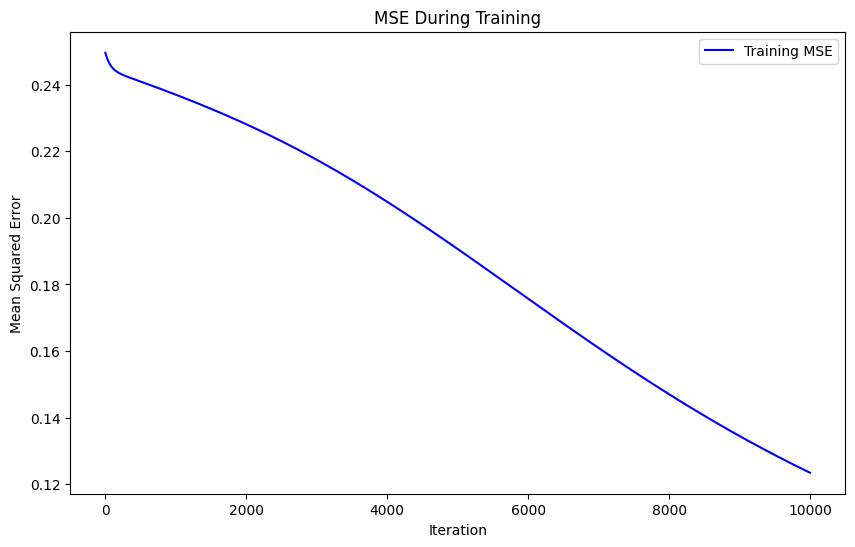

Accuracy on test set : 87.50%
Accuracy on train set: 90.25%


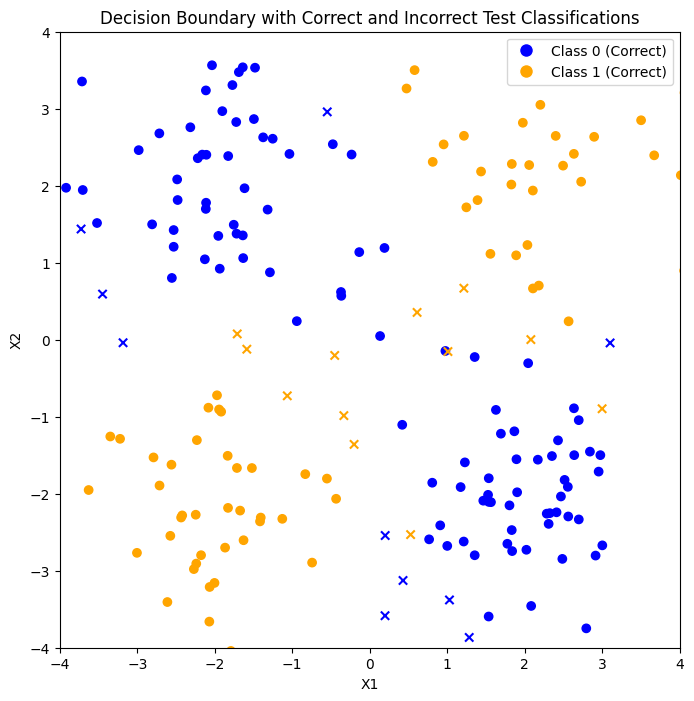

Number of correctly classified points: 175
Number of incorrectly classified points: 25


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Initialize and train the MLPClass model
input_dim = X_train.shape[1]
model = MLPClass(input_dim=input_dim, hidden_dim=8, learning_rate=0.03, n_iterations=10000)
model.fit(X_train, y_train)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(model.get_mse_history(), label="Training MSE", color="blue")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("MSE During Training")
plt.legend()
plt.show()

# Make predictions on the test and train sets
y_pred = model.predict(X_test)
y_pred_labels = y_pred  # Apply threshold to convert probabilities to binary labels

y_pred_train = model.predict(X_train)
y_pred_train_labels = (y_pred_train > 0.5).astype(int)  # Apply threshold to convert probabilities to binary labels

# Calculate accuracy for both test and train sets
accuracy = accuracy_score(y_test, y_pred_labels)
accuracy_train = accuracy_score(y_train, y_pred_train_labels)
print(f"Accuracy on test set : {accuracy * 100:.2f}%")
print(f"Accuracy on train set: {accuracy_train * 100:.2f}%")

# Separate correctly and incorrectly classified points, keeping class colors
correct_x, correct_y, correct_colors = [], [], []
incorrect_x, incorrect_y, incorrect_colors = [], [], []

for i in range(len(y_test)):
    if y_pred_labels[i] == y_test[i]:  # Correct classification
        correct_x.append(X_test[i, 0])
        correct_y.append(X_test[i, 1])
        correct_colors.append('blue' if y_test[i] == 0 else 'orange')
    else:  # Incorrect classification
        incorrect_x.append(X_test[i, 0])
        incorrect_y.append(X_test[i, 1])
        incorrect_colors.append('blue' if y_test[i] == 0 else 'orange')

# Plot decision boundary and test data points
plt.figure(figsize=(8, 8))

# Plot correctly classified points (circles) and incorrectly classified points (crosses) with class color
plt.scatter(correct_x, correct_y, c=correct_colors, marker='o', label='Correctly Classified')
plt.scatter(incorrect_x, incorrect_y, c=incorrect_colors, marker='x', label='Incorrectly Classified')

# Adding legend for color and boundary
correct_class_label = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Class 0 (Correct)')
incorrect_class_label = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Class 1 (Correct)')
plt.legend(handles=[correct_class_label, incorrect_class_label])

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Decision Boundary with Correct and Incorrect Test Classifications")
plt.show()

print("Number of correctly classified points:", len(correct_x))
print("Number of incorrectly classified points:", len(incorrect_x))


## 2. Universal Approximation Theorem

The Universal Approximation Theorem states that a neural network with at least one hidden layer and a nonlinear activation function can approximate any continuous function on a bounded domain—given enough neurons.

In simple terms: Neural networks are very flexible function approximators.

But keep in mind:
* It does not say how many neurons you need
* It does not guarantee that training will find the right solution
* It does not mean every architecture works equally well

### Interactive demo (try it!)
[Tensorflow offers a nice playground](https://playground.tensorflow.org/) to experiment (and nicely visualize) how MLPs with different numbers of layers are able to handle different data sets.
* Try removing hidden layers → the model fails
* Add more neurons/layers → decision boundary becomes more flexible
* Change activation (ReLU, tanh, etc.)

Observe how the network gradually learns complex shapes. **Remember**: Neural networks don't "memorize shapes", they build complex functions by composing many simple nonlinear transformations.

## 3. Using PyTorch to Build a Multi-Layer Perceptron Model

In this task, we implement and evaluate a Multi-Layer Perceptron (MLP) model using the **PyTorch** library. We use a simple MLP architecture with one hidden layer and test how changing the hidden layer size affects model performance on the MNIST dataset.

The MNIST dataset consists of grayscale images of handwritten digits from 0 to 9. The goal is to correctly classify each image into one of the 10 digit classes.

Using PyTorch allows us to define, train, and evaluate neural networks in a flexible way. This task demonstrates how model capacity, controlled by the hidden layer size, can affect accuracy and generalization.

---

### Explanation and task description

#### 1. Data Preparation

Use the MNIST dataset, which is a classic dataset for image classification tasks. It contains 70,000 grayscale images of handwritten digits:

- 60,000 training images
- 10,000 test images

Each image has size `28 × 28` pixels. For this MLP model, each image is flattened into a `784`-dimensional input vector.

The pixel values are normalized from the range `[0, 255]` to `[0, 1]`.

In PyTorch, labels are usually stored as integer class indices instead of one-hot encoded vectors. Therefore, the labels are represented as integers from `0` to `9`.

#### 2. Model Definition

Define an MLP model in PyTorch with:

- an input layer of size `784`
- one hidden layer of configurable size
- ReLU activation after the hidden layer
- an output layer of size `10`, one output for each digit class

The model returns raw output scores, also called **logits**.

Unlike some TensorFlow/Keras implementations, we do not apply `softmax` inside the model. This is because PyTorch's `nn.CrossEntropyLoss` already applies `log_softmax` internally.

#### 3. Loss Function and Optimizer

We train the model using `nn.CrossEntropyLoss()` for multi-class classification and Adam optimizer for updating model parameters. `CrossEntropyLoss` expects raw logits from the model and integer class labels.

#### 4. Train the Model

Train the model for a fixed number of epochs, for example `10`.

During training, monitor:

- training loss
- training accuracy
- validation or test loss
- validation or test accuracy

This allows us to observe whether the model is learning and whether it starts to overfit.

#### 5. Evaluate Model Performance

After training, evaluate the model on the test set.

Calculate and display:

- final test accuracy
- confusion matrix for all digit classes
- loss and accuracy curves during training

The confusion matrix helps us understand which digits are classified correctly and which digits are commonly confused.

By comparing models with different hidden layer sizes, we can study how the capacity of an MLP affects classification performance on MNIST.

## 3.1 Data Preparation

In [6]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch.utils.data import TensorDataset, DataLoader

# Load MNIST dataset
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

# Features and labels
X = mnist["data"].astype(np.float32)
y = mnist["target"].astype(np.int64)

# Normalize pixel values from [0, 255] to [0, 1]
X = X / 255.0


def load_all_classes(X, y, num_train=60000, num_test=10000):
    """
    Load MNIST data for all digits (0-9) and split into train and test sets.

    Parameters:
    - X: np.array, feature data
    - y: np.array, target labels as integers
    - num_train: int, number of training samples
    - num_test: int, number of test samples

    Returns:
    - X_train, y_train: training data and integer labels
    - X_test, y_test: test data and integer labels
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=num_train,
        test_size=num_test,
        random_state=42,
        stratify=y
    )

    return X_train, y_train, X_test, y_test


# Use smaller subset for faster experiments
X_train, y_train, X_test, y_test = load_all_classes(
    X, y, num_train=1000, num_test=1000
)

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create PyTorch datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create PyTorch dataloaders
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Display shapes
print("Training set shape:", X_train_tensor.shape, y_train_tensor.shape)
print("Test set shape:", X_test_tensor.shape, y_test_tensor.shape)

Training set shape: torch.Size([1000, 784]) torch.Size([1000])
Test set shape: torch.Size([1000, 784]) torch.Size([1000])


## 3.2 Model Architechture

Epoch [1/20] Train Loss: 2.0474, Train Acc: 0.4480, Val Loss: 1.6745, Val Acc: 0.6680
Epoch [2/20] Train Loss: 1.4122, Train Acc: 0.7450, Val Loss: 1.1149, Val Acc: 0.7880
Epoch [3/20] Train Loss: 0.9833, Train Acc: 0.7950, Val Loss: 0.8122, Val Acc: 0.8260
Epoch [4/20] Train Loss: 0.7484, Train Acc: 0.8460, Val Loss: 0.6529, Val Acc: 0.8570
Epoch [5/20] Train Loss: 0.6088, Train Acc: 0.8740, Val Loss: 0.5689, Val Acc: 0.8690
Epoch [6/20] Train Loss: 0.5208, Train Acc: 0.8820, Val Loss: 0.5195, Val Acc: 0.8780
Epoch [7/20] Train Loss: 0.4579, Train Acc: 0.8880, Val Loss: 0.4744, Val Acc: 0.8850
Epoch [8/20] Train Loss: 0.4083, Train Acc: 0.9030, Val Loss: 0.4420, Val Acc: 0.8990
Epoch [9/20] Train Loss: 0.3691, Train Acc: 0.9110, Val Loss: 0.4237, Val Acc: 0.9010
Epoch [10/20] Train Loss: 0.3403, Train Acc: 0.9180, Val Loss: 0.4191, Val Acc: 0.8950
Epoch [11/20] Train Loss: 0.3173, Train Acc: 0.9150, Val Loss: 0.4002, Val Acc: 0.8990
Epoch [12/20] Train Loss: 0.2869, Train Acc: 0.9350,

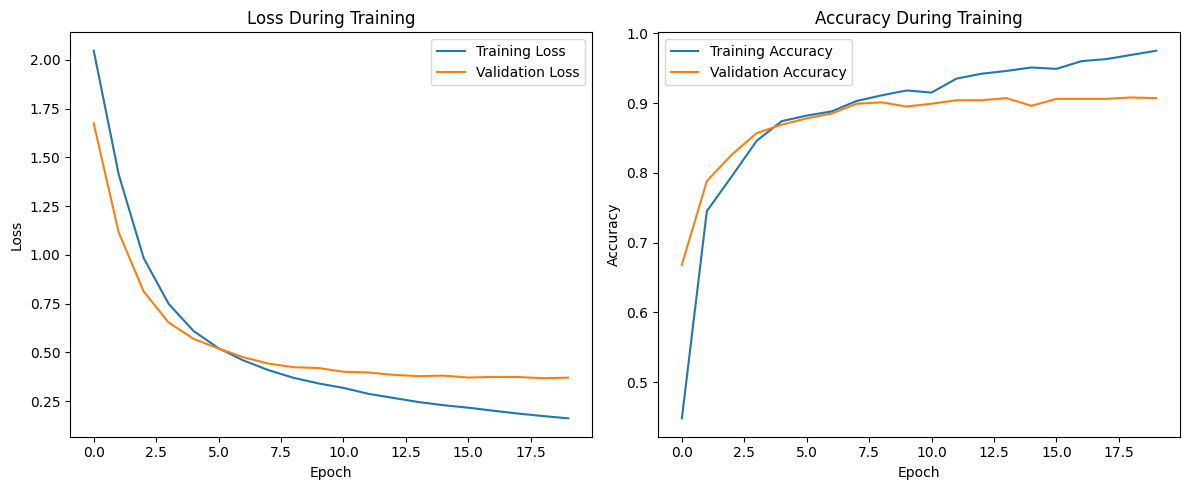

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define the MLP model architecture
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=32, output_size=10):
        super(MLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),  # Hidden layer
            nn.ReLU(),                           # ReLU activation
            nn.Linear(hidden_size, output_size)  # Output layer: raw logits
        )

    def forward(self, x):
        return self.network(x)


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create model
model = MLP(
    input_size=X_train_tensor.shape[1],
    hidden_size=32,
    output_size=10
).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Training settings
epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


# Helper function for evaluation
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


# Train the model
for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward pass and parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    val_loss, val_accuracy = evaluate_model(
        model, test_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_accuracy:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_accuracy:.4f}"
    )


# Plot the loss and accuracy over epochs
plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss During Training")
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy During Training")
plt.legend()

plt.tight_layout()
plt.show()

### Experiment: Evaluating the Impact of Hidden Layer Size on MLP Performance

In this experiment, we study how the size of the hidden layer affects the performance of a simple Multi-Layer Perceptron (MLP) on the MNIST digit classification task.

We train several MLP models with different numbers of neurons in the hidden layer and compare their training and test accuracy after 10 epochs.

By comparing different hidden layer sizes, we can observe how model capacity affects learning and generalization.

**Tasks:**

1. **Define Hidden Layer Sizes**

   Test the following hidden layer sizes:

   ```python
   [1, 2, 4, 8, 16, 32, 64, 128]

2. **Model Setup**

   For each hidden layer size, define an MLP model in PyTorch with:

   - input layer of size `784`
   - one hidden layer with the selected size
   - ReLU activation after the hidden layer
   - output layer of size `10`

   The model outputs raw logits. We do not apply `softmax` inside the model because `nn.CrossEntropyLoss()` applies it internally.

3. **Train the Model**

   Train each model for 10 epochs using:

   - batch size `32`
   - Adam optimizer
   - `nn.CrossEntropyLoss()`

4. **Evaluate Accuracy**

   For each hidden layer size, calculate:

   - training accuracy
   - test accuracy

   Store these values for comparison.

5. **Visualize Results**

   Plot the training and test accuracy for each hidden layer size to visualize how hidden layer size affects model performance.


Hidden Size: 1
Train: 0.195 Test: 0.201
Hidden Size: 2
Train: 0.374 Test: 0.37
Hidden Size: 4
Train: 0.684 Test: 0.685
Hidden Size: 8
Train: 0.861 Test: 0.833
Hidden Size: 16
Train: 0.92 Test: 0.884
Hidden Size: 32
Train: 0.934 Test: 0.897
Hidden Size: 64
Train: 0.956 Test: 0.905
Hidden Size: 128
Train: 0.973 Test: 0.9


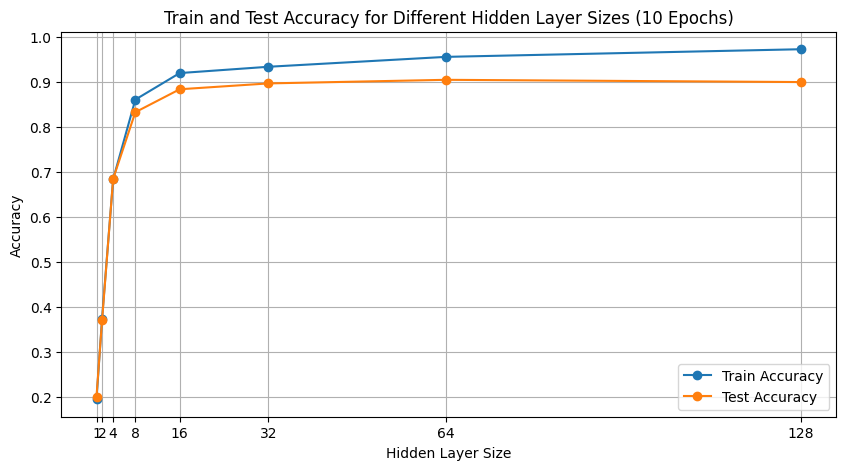

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Define hidden layer sizes to test
hidden_layer_sizes = [1, 2, 4, 8, 16, 32, 64, 128]

train_accuracies = []
test_accuracies = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO: Based on the code from above,
# - vary the hidden layer size
# - for each one build a model, train it (try only a couple epochs, e.g., 10)
# - append the accuracies to the different lists
# Loop over different hidden layer sizes


# Suggested order:

# 1. Define MLP model
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=32, output_size=10):
        super(MLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.network(x)

# 2. Helper function to train one model
def train_one_model(model, train_loader, criterion, optimizer, device, epochs=10):
    for epoch in range(epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

# 3. Helper function to calculate accuracy
def calculate_accuracy(model, data_loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

# 4. Loop over different hidden layer sizes
for hidden_size in hidden_layer_sizes:
    print("Hidden Size:", hidden_size)

    model = MLP(input_size=784, hidden_size=hidden_size, output_size=10)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    # train model
    train_one_model(model, train_loader, criterion, optimizer, device, epochs=10)

    # calculate accuracy
    train_acc = calculate_accuracy(model, train_loader, device)
    test_acc = calculate_accuracy(model, test_loader, device)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print("Train:", train_acc, "Test:", test_acc)


# Plot train and test accuracy
plt.figure(figsize=(10, 5))
plt.plot(hidden_layer_sizes, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(hidden_layer_sizes, test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Hidden Layer Size")
plt.ylabel("Accuracy")
plt.title("Train and Test Accuracy for Different Hidden Layer Sizes (10 Epochs)")
plt.xticks(hidden_layer_sizes)
plt.legend()
plt.grid()
plt.show()

### Analyzing Model Complexity by Hidden Layer Size

In this task, we analyze how the number of trainable parameters in a Multi-Layer Perceptron (MLP) changes when using different hidden layer sizes.

The model is tested on the MNIST dataset, where each image is represented as a flattened `784`-dimensional vector. The output layer has `10` neurons, one for each digit class.

By comparing models with different hidden layer sizes, we can understand how model complexity increases and how this affects computational cost and learning capacity.

---

### Explanation of Parameter Calculation

Each MLP model has two linear layers:

1. **Input Layer to Hidden Layer**

   The number of parameters between the input layer and the hidden layer is:

   $$
   \text{Parameters} = (\text{Input Dimension} + 1) \times \text{Hidden Layer Size}
   $$

   The `+1` accounts for the bias term.

2. **Hidden Layer to Output Layer**

   The number of parameters between the hidden layer and the output layer is:

   $$
   \text{Parameters} = (\text{Hidden Layer Size} + 1) \times \text{Output Dimension}
   $$

   The `+1` accounts for the bias term in the output layer.

3. **Total Parameters**

   The total number of parameters is the sum of the parameters from both layers.

---

### Tasks

1. **Loop through Hidden Layer Sizes**

   Test the following hidden layer sizes:

   ```python
   [1, 2, 4, 8, 16, 32, 64, 128]

2. **Define the Model**

   For each hidden layer size, define an MLP model in PyTorch with:

   - input layer of size `784`
   - one hidden layer of the selected size
   - ReLU activation after the hidden layer
   - output layer of size `10`

   The model outputs raw logits. We do not apply `softmax` inside the model because PyTorch's `nn.CrossEntropyLoss()` applies it internally.

3. **Calculate and Store Parameters**

   Count the total number of trainable parameters for each model configuration.

4. **Plot the Results**

   Visualize the total number of parameters for each hidden layer size to understand how model complexity scales with hidden layer size.

Hidden Size: 1
Total parameters: 805
Hidden Size: 2
Total parameters: 1600
Hidden Size: 4
Total parameters: 3190
Hidden Size: 8
Total parameters: 6370
Hidden Size: 16
Total parameters: 12730
Hidden Size: 32
Total parameters: 25450
Hidden Size: 64
Total parameters: 50890
Hidden Size: 128
Total parameters: 101770


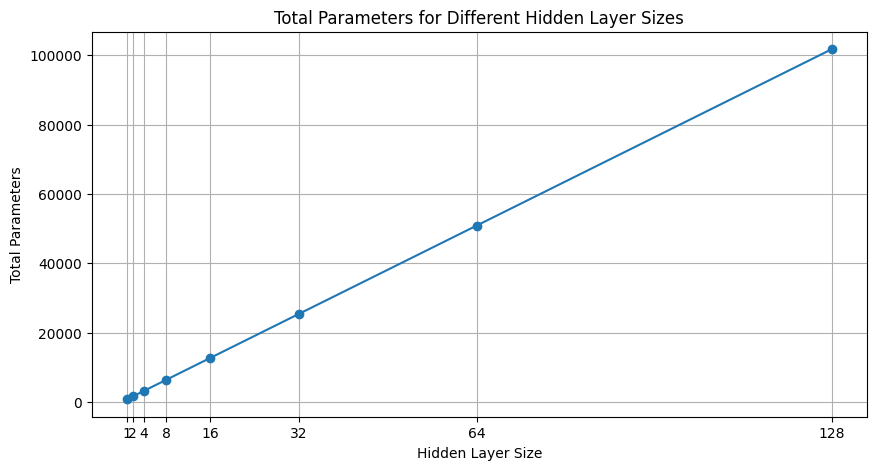

In [15]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

input_dim = 784
output_dim = 10

hidden_layer_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
total_params_list = []

# helper function to count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for hidden_size in hidden_layer_sizes:
   # TODO:
    # Calculate for each layer size how many neurons are required
    # Compare the values
    # Define the model with one hidden layer of `hidden_size`, you can use defined MLP model from above
    print("Hidden Size:", hidden_size)

    # modell mit aktueller hidden size erstellen
    model = MLP(input_size=input_dim, hidden_size=hidden_size, output_size=output_dim)

    # parameter zählen
    total_params = count_parameters(model)

    # speichern für den plot
    total_params_list.append(total_params)

    print("Total parameters:", total_params)



plt.figure(figsize=(10, 5))
plt.plot(hidden_layer_sizes, total_params_list, marker="o")
plt.xlabel("Hidden Layer Size")
plt.ylabel("Total Parameters")
plt.title("Total Parameters for Different Hidden Layer Sizes")
plt.xticks(hidden_layer_sizes)
plt.grid()
plt.show()

### Optional: Visualizing the Computational Graph

As an outlook and preparation for the next lecture, you may want to try this out, but you don't have to.

A computational graph represents the sequence of operations that the model performs during the forward pass.

For this MLP, the graph shows how the input tensor passes through:

1. a linear layer,
2. a ReLU activation function,
3. another linear layer,
4. the final output logits.

In PyTorch, the computational graph is created dynamically during the forward pass. This graph is also used during backpropagation to compute gradients and update the model parameters.

We can visualize this graph using `torchviz`.

In [ ]:
!pip install torchviz

In [ ]:
from torchviz import make_dot

hidden_size = 32
model = MLP(input_size=784, hidden_size=hidden_size, output_size=10)

# Example input: one MNIST image flattened into 784 features
x = torch.randn(1, 784)

# Forward pass
output = model(x)

# Draw computational graph
graph = make_dot(output, params=dict(model.named_parameters()))
graph.render("mlp_computational_graph", format="png")

graph

#### Feedback
To improve the exercises, we would be happy to hear your feedback. Please take 2min to fill out an [anonymous questionnaire](https://survey.mbp.tf.uni-bielefeld.de/index.php?r=survey/index&sid=877889).